## 1. Learning Algorithms
Implement a simple learning algorithm (Linear Regression) using Gradient Descent. Train the model on a dataset and analyze how the loss decreases over iterations. Plot the learning curve.

Estimated parameters (theta):
[[4.22215108]
 [2.96846751]]


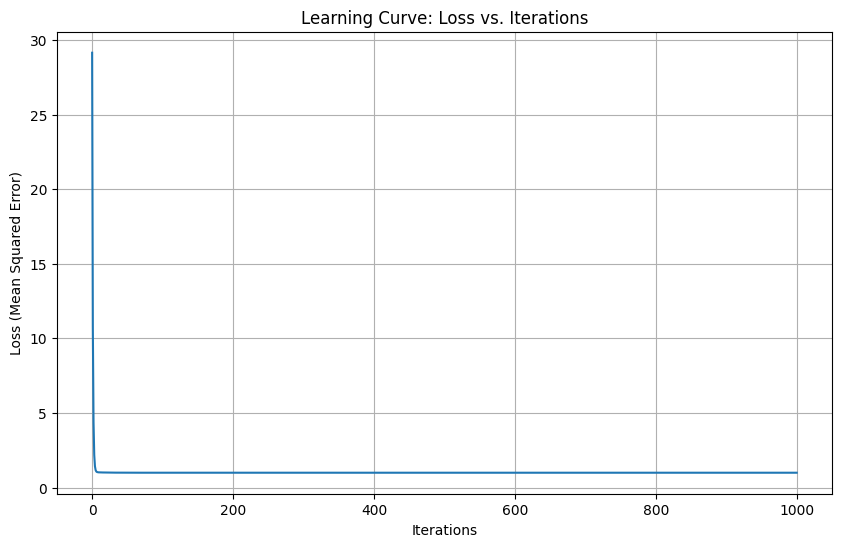

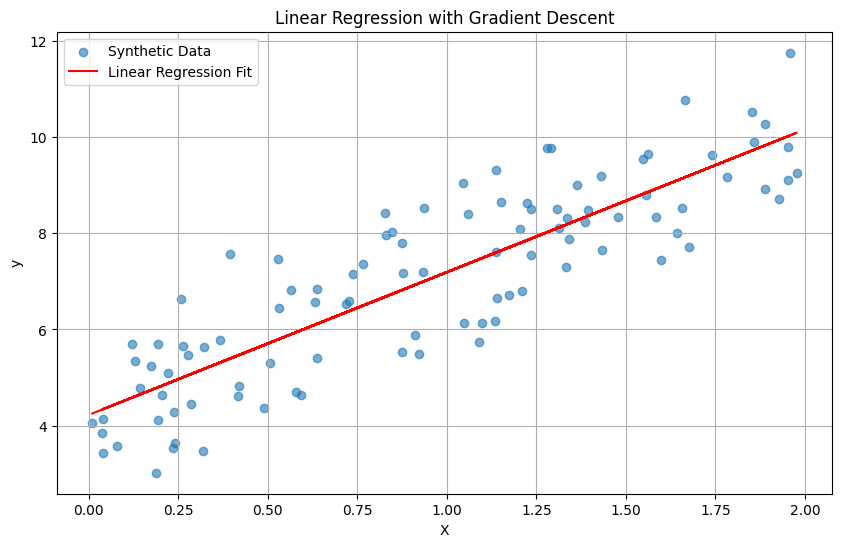

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]

def gradient_descent(X, y, learning_rate, n_iterations):
    m = len(y)
    theta = np.random.randn(X.shape[1], 1)
    losses = []

    for iteration in range(n_iterations):
        gradients = 2/m * X.T @ (X @ theta - y)
        theta = theta - learning_rate * gradients
        loss = np.mean((X @ theta - y)**2)
        losses.append(loss)
    return theta, losses

learning_rate = 0.1
n_iterations = 1000
theta_final, losses = gradient_descent(X_b, y, learning_rate, n_iterations)

print(f"Estimated parameters (theta):\n{theta_final}")

plt.figure(figsize=(10, 6))
plt.plot(range(n_iterations), losses)
plt.xlabel("Iterations")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("Learning Curve: Loss vs. Iterations")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, label="Synthetic Data")
plt.plot(X, X_b @ theta_final, color='red', label="Linear Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression with Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

## 2. Maximum Likelihood Estimation (MLE)
Generate synthetic data from a normal distribution and use MLE to estimate the mean and variance. Compare estimated values with actual parameters.

In [2]:
import numpy as np

np.random.seed(42)
actual_mean = 5
actual_std = 2
synthetic_data = np.random.normal(loc=actual_mean, scale=actual_std, size=1000)

estimated_mean = np.mean(synthetic_data)

estimated_variance = np.var(synthetic_data)
estimated_std = np.sqrt(estimated_variance)

print(f"Actual Mean: {actual_mean:.4f}")
print(f"Estimated Mean: {estimated_mean:.4f}")
print(f"Actual Standard Deviation: {actual_std:.4f}")
print(f"Estimated Standard Deviation: {estimated_std:.4f}")
print(f"Actual Variance: {actual_std**2:.4f}")
print(f"Estimated Variance: {estimated_variance:.4f}")

Actual Mean: 5.0000
Estimated Mean: 5.0387
Actual Standard Deviation: 2.0000
Estimated Standard Deviation: 1.9575
Actual Variance: 4.0000
Estimated Variance: 3.8316


## 3. Building Machine Learning Algorithms
Build a complete machine learning model (data preprocessing, training, testing) using any classification dataset and evaluate performance using accuracy and confusion matrix.

Accuracy: 0.9111

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



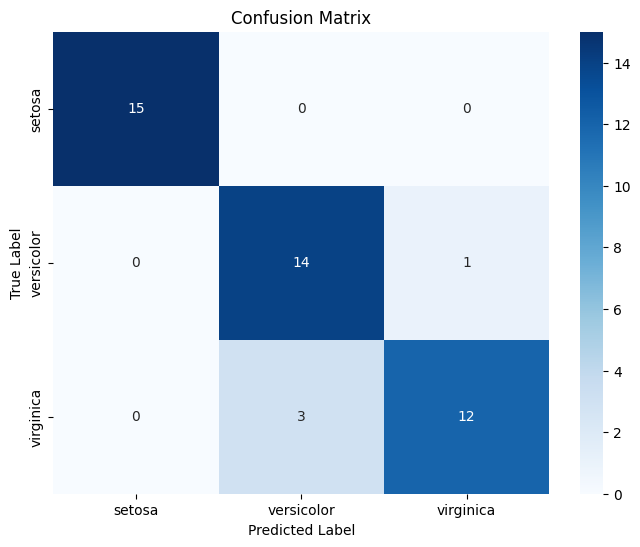

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 4. Neural Networks
Design a simple neural network with one hidden layer and train it on a small dataset. Analyze how the network learns non-linear patterns.

Test accuracy: 0.8667


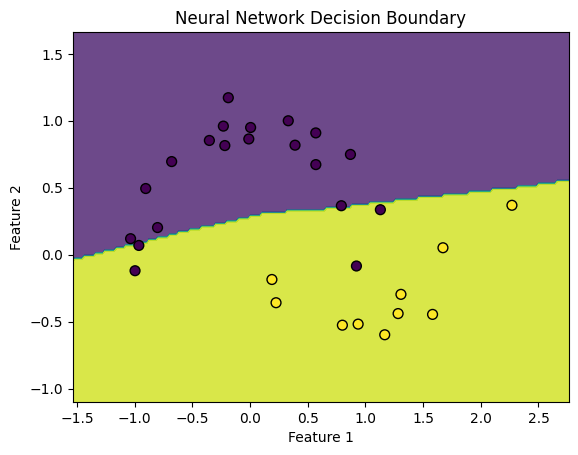

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42, activation='relu', solver='adam')

mlp.fit(X_train_scaled, y_train)

accuracy = mlp.score(X_test_scaled, y_test)
print(f"Test accuracy: {accuracy:.4f}")

def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=50)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_decision_boundary(X_test, y_test, mlp, "Neural Network Decision Boundary")

## 5. Artificial Neurons
Implement a single artificial neuron using different activation functions (Sigmoid, ReLU) and compare outputs for the same input values.

Output with Sigmoid activation: 0.4231
Output with ReLU activation: 0.0000


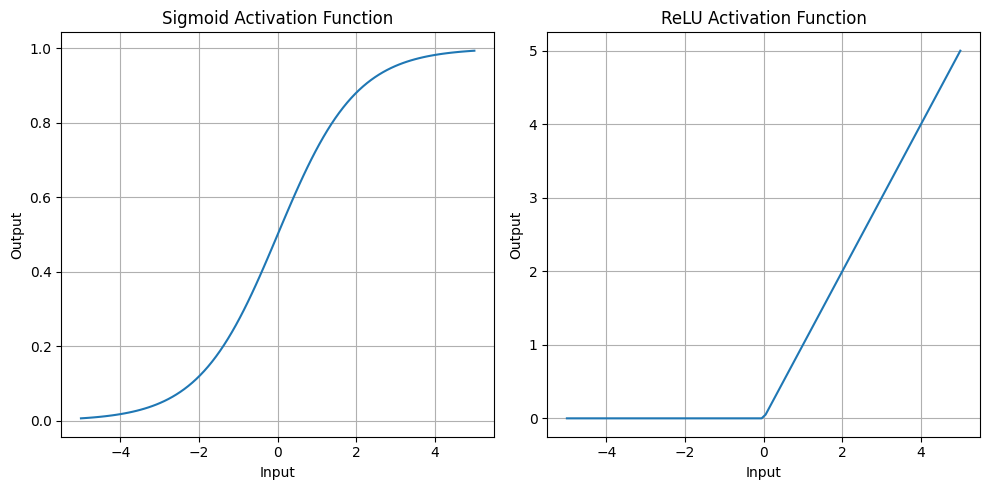

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def neuron_output(inputs, weights, bias, activation_fn):
    linear_output = np.dot(inputs, weights) + bias
    return activation_fn(linear_output)

inputs = np.array([0.5, -0.2, 0.8])
weights = np.array([0.1, 0.3, -0.5])
bias = 0.1

sigmoid_output = neuron_output(inputs, weights, bias, sigmoid)
print(f"Output with Sigmoid activation: {sigmoid_output:.4f}")

relu_output = neuron_output(inputs, weights, bias, relu)
print(f"Output with ReLU activation: {relu_output:.4f}")

x_values = np.linspace(-5, 5, 100)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x_values, sigmoid(x_values))
plt.title('Sigmoid Activation Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_values, relu(x_values))
plt.title('ReLU Activation Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Perceptron and Multilayer Perceptron (MLP)
a) Implement the Perceptron algorithm for binary classification and test it on linearly separable and non-linearly separable datasets. Analyze the results.
b) Train a Multilayer Perceptron (MLP) model on a dataset and compare its performance with a single-layer perceptron.

--- Perceptron on Linearly Separable Data ---
Accuracy on linearly separable data: 0.8400


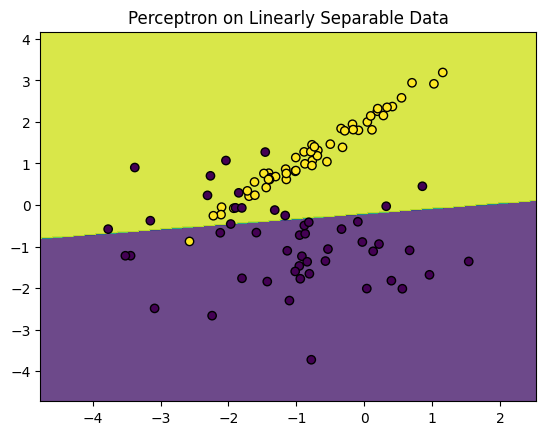


--- Perceptron on Non-Linearly Separable Data ---
Accuracy on non-linearly separable data: 0.8800


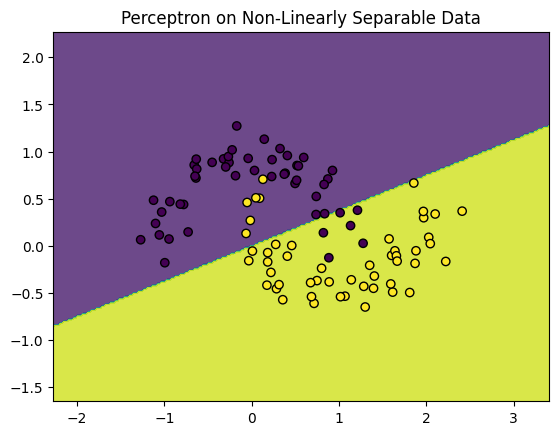


--- Multilayer Perceptron (MLP) ---
MLP Accuracy on test data: 0.9000


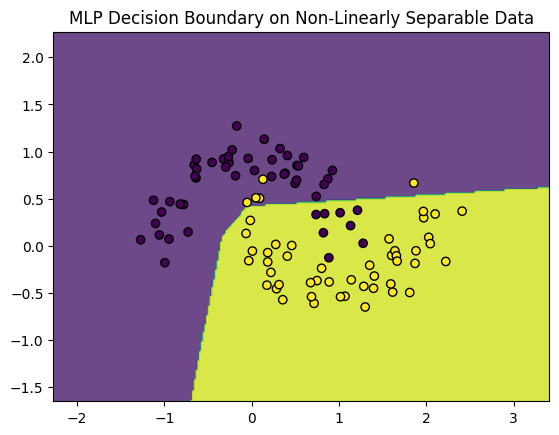


Analysis: The Perceptron struggles with non-linearly separable data, as its decision boundary is always linear. The MLP, with its hidden layers and non-linear activation functions, is able to learn complex, non-linear decision boundaries and achieves much higher accuracy on such datasets.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

def plot_perceptron_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title(title)
    plt.show()

print("--- Perceptron on Linearly Separable Data ---")

X_linear, y_linear = make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=2,
                                         n_clusters_per_class=1, random_state=4)
perceptron_linear = Perceptron(random_state=42, max_iter=1000)
perceptron_linear.fit(X_linear, y_linear)
y_pred_linear = perceptron_linear.predict(X_linear)
print(f"Accuracy on linearly separable data: {accuracy_score(y_linear, y_pred_linear):.4f}")
plot_perceptron_decision_boundary(X_linear, y_linear, perceptron_linear, "Perceptron on Linearly Separable Data")

print("\n--- Perceptron on Non-Linearly Separable Data ---")

X_nonlinear, y_nonlinear = make_moons(n_samples=100, noise=0.15, random_state=42)
perceptron_nonlinear = Perceptron(random_state=42, max_iter=1000)
perceptron_nonlinear.fit(X_nonlinear, y_nonlinear)
y_pred_nonlinear = perceptron_nonlinear.predict(X_nonlinear)
print(f"Accuracy on non-linearly separable data: {accuracy_score(y_nonlinear, y_pred_nonlinear):.4f}")
plot_perceptron_decision_boundary(X_nonlinear, y_nonlinear, perceptron_nonlinear, "Perceptron on Non-Linearly Separable Data")

print("\n--- Multilayer Perceptron (MLP) ---")
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(X_nonlinear, y_nonlinear, test_size=0.3, random_state=42)

mlp_model = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42, activation='relu', solver='adam')
mlp_model.fit(X_train_mlp, y_train_mlp)

y_pred_mlp = mlp_model.predict(X_test_mlp)
print(f"MLP Accuracy on test data: {accuracy_score(y_test_mlp, y_pred_mlp):.4f}")

def plot_mlp_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title(title)
    plt.show()

plot_mlp_decision_boundary(X_nonlinear, y_nonlinear, mlp_model, "MLP Decision Boundary on Non-Linearly Separable Data")

print("\nAnalysis: The Perceptron struggles with non-linearly separable data, as its decision boundary is always linear. The MLP, with its hidden layers and non-linear activation functions, is able to learn complex, non-linear decision boundaries and achieves much higher accuracy on such datasets.")

## 7. Forward Propagation and Backpropagation Algorithm
a) Manually compute forward propagation for a small neural network (given weights and inputs) and verify the output using code.
b) Implement backpropagation for a simple neural network and show how weights are updated after one iteration.

In [7]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

print("--- Forward Propagation ---")

X_fp = np.array([0.5, 0.8])

w_h = np.array([[0.1, 0.4],
                [0.2, 0.5]])
b_h = np.array([0.3, 0.6])
w_o = np.array([[0.7],
                [0.9]])
b_o = np.array([0.1])

z_h1 = X_fp[0]*w_h[0,0] + X_fp[1]*w_h[1,0] + b_h[0]
z_h2 = X_fp[0]*w_h[0,1] + X_fp[1]*w_h[1,1] + b_h[1]
z_h = np.array([z_h1, z_h2])

a_h = sigmoid(z_h)

z_o1 = a_h[0]*w_o[0,0] + a_h[1]*w_o[1,0] + b_o[0]
z_o = np.array([z_o1])

y_pred_manual = sigmoid(z_o)

print(f"Manual Forward Propagation Output: {y_pred_manual[0]:.4f}")

def forward_propagate(X, w_h, b_h, w_o, b_o):
    z_h = np.dot(X, w_h) + b_h
    a_h = sigmoid(z_h)

    z_o = np.dot(a_h, w_o) + b_o
    y_pred = sigmoid(z_o)
    return y_pred, a_h, z_h

y_pred_code, a_h_code, z_h_code = forward_propagate(X_fp, w_h, b_h, w_o, b_o)
print(f"Code Verified Forward Propagation Output: {y_pred_code[0]:.4f}")

print("\n--- Backpropagation (One Iteration) ---")
X_bp = np.array([[0.5, 0.8]])
y_true = np.array([[0.7]])

w_h_bp = np.array([[0.1, 0.4],
                   [0.2, 0.5]])
b_h_bp = np.array([[0.3, 0.6]])
w_o_bp = np.array([[0.7],
                   [0.9]])
b_o_bp = np.array([[0.1]])

learning_rate = 0.1

print("Initial Weights (Hidden Layer):\n", w_h_bp)
print("Initial Biases (Hidden Layer):\n", b_h_bp)
print("Initial Weights (Output Layer):\n", w_o_bp)
print("Initial Biases (Output Layer):\n", b_o_bp)

y_pred_bp, a_h_bp, z_h_bp = forward_propagate(X_bp, w_h_bp, b_h_bp, w_o_bp, b_o_bp)

error = y_true - y_pred_bp

delta_o = error * sigmoid_derivative(y_pred_bp)

error_hidden = delta_o @ w_o_bp.T
delta_h = error_hidden * sigmoid_derivative(a_h_bp)

dW_o = a_h_bp.T @ delta_o
db_o = delta_o
w_o_bp_updated = w_o_bp + learning_rate * dW_o
b_o_bp_updated = b_o_bp + learning_rate * db_o

dW_h = X_bp.T @ delta_h
db_h = delta_h
w_h_bp_updated = w_h_bp + learning_rate * dW_h
b_h_bp_updated = b_h_bp + learning_rate * db_h

print("\nUpdated Weights (Hidden Layer) after one iteration:\n", w_h_bp_updated)
print("Updated Biases (Hidden Layer) after one iteration:\n", b_h_bp_updated)
print("Updated Weights (Output Layer) after one iteration:\n", w_o_bp_updated)
print("Updated Biases (Output Layer) after one iteration:\n", b_o_bp_updated)

--- Forward Propagation ---
Manual Forward Propagation Output: 0.7736
Code Verified Forward Propagation Output: 0.7736

--- Backpropagation (One Iteration) ---
Initial Weights (Hidden Layer):
 [[0.1 0.4]
 [0.2 0.5]]
Initial Biases (Hidden Layer):
 [[0.3 0.6]]
Initial Weights (Output Layer):
 [[0.7]
 [0.9]]
Initial Biases (Output Layer):
 [[0.1]]

Updated Weights (Hidden Layer) after one iteration:
 [[0.09989418 0.39989675]
 [0.19983069 0.49983481]]
Updated Biases (Hidden Layer) after one iteration:
 [[0.29978836 0.59979351]]
Updated Weights (Output Layer) after one iteration:
 [[0.69919417]
 [0.89900881]]
Updated Biases (Output Layer) after one iteration:
 [[0.09871027]]


## 8. Gradient Descent and Stochastic Gradient Descent (SGD)
a) Implement Gradient Descent to minimize a cost function and analyze the effect of learning rate on convergence speed.
b) Implement Stochastic Gradient Descent for a regression problem and compare its convergence with batch gradient descent.

--- Gradient Descent and Learning Rate Analysis ---


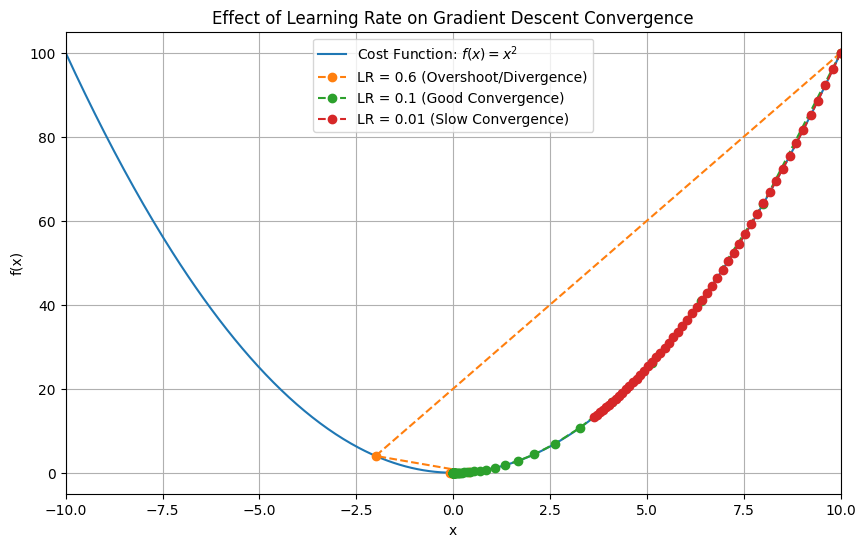

Analysis of Learning Rate:
- A large learning rate (0.6) can cause the algorithm to overshoot the minimum or even diverge.
- A medium learning rate (0.1) allows for stable and relatively fast convergence.
- A small learning rate (0.01) leads to slow convergence, requiring many iterations to reach the minimum.

--- Stochastic Gradient Descent (SGD) vs. Batch Gradient Descent ---


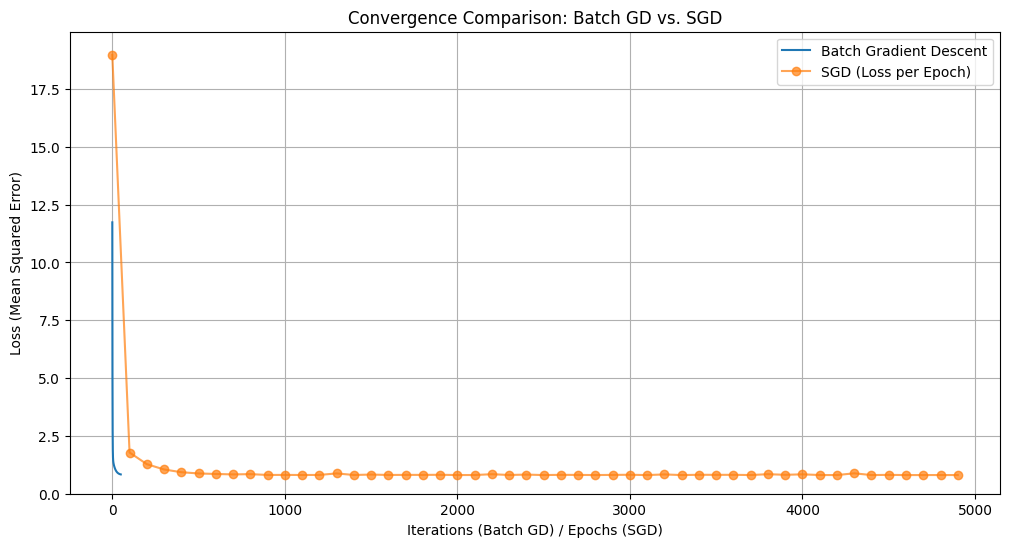


Analysis of Convergence:
- Batch Gradient Descent has a smoother convergence path because it calculates the gradient using the entire dataset at each step.
- Stochastic Gradient Descent has a noisier convergence path due to updating weights based on a single training example at a time. However, it can reach the vicinity of the minimum much faster, especially for large datasets, and can escape local minima more easily.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

print("--- Gradient Descent and Learning Rate Analysis ---")

def cost_function(x):
    return x**2

def gradient(x):
    return 2 * x

def gradient_descent_optimizer(initial_x, learning_rate, n_iterations):
    x = initial_x
    path = [x]
    for _ in range(n_iterations):
        grad = gradient(x)
        x = x - learning_rate * grad
        path.append(x)
    return np.array(path)

initial_x = 10
n_iterations_gd = 50

lr_fast = 0.6
lr_medium = 0.1
lr_slow = 0.01

path_fast = gradient_descent_optimizer(initial_x, lr_fast, n_iterations_gd)
path_medium = gradient_descent_optimizer(initial_x, lr_medium, n_iterations_gd)
path_slow = gradient_descent_optimizer(initial_x, lr_slow, n_iterations_gd)

plt.figure(figsize=(10, 6))
x_range = np.linspace(-10, 10, 400)
plt.plot(x_range, cost_function(x_range), label='Cost Function: $f(x) = x^2$')
plt.plot(path_fast, cost_function(path_fast), 'o--', label=f'LR = {lr_fast} (Overshoot/Divergence)')
plt.plot(path_medium, cost_function(path_medium), 'o--', label=f'LR = {lr_medium} (Good Convergence)')
plt.plot(path_slow, cost_function(path_slow), 'o--', label=f'LR = {lr_slow} (Slow Convergence)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Effect of Learning Rate on Gradient Descent Convergence')
plt.legend()
plt.grid(True)
plt.xlim([-10, 10])
plt.ylim([-5, 105])
plt.show()

print("Analysis of Learning Rate:\n- A large learning rate (0.6) can cause the algorithm to overshoot the minimum or even diverge.")
print("- A medium learning rate (0.1) allows for stable and relatively fast convergence.")
print("- A small learning rate (0.01) leads to slow convergence, requiring many iterations to reach the minimum.")

print("\n--- Stochastic Gradient Descent (SGD) vs. Batch Gradient Descent ---")

np.random.seed(42)
X_reg = 2 * np.random.rand(100, 1)
y_reg = 4 + 3 * X_reg + np.random.randn(100, 1)
X_b_reg = np.c_[np.ones((100, 1)), X_reg]

def mse_cost(X, y, theta):
    return np.mean((X @ theta - y)**2)

def mse_gradient(X, y, theta):
    return 2/len(y) * X.T @ (X @ theta - y)

def batch_gradient_descent(X, y, learning_rate, n_iterations):
    theta = np.random.randn(X.shape[1], 1)
    losses = []
    for _ in range(n_iterations):
        grad = mse_gradient(X, y, theta)
        theta = theta - learning_rate * grad
        losses.append(mse_cost(X, y, theta))
    return theta, losses

def sgd(X, y, learning_rate, n_epochs):
    m = len(y)
    theta = np.random.randn(X.shape[1], 1)
    losses = []
    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]
            grad = 2 * xi.T @ (xi @ theta - yi)
            theta = theta - learning_rate * grad
            losses.append(mse_cost(X, y, theta))
    return theta, losses

lr_bgd = 0.1
n_iterations_bgd = 50
theta_bgd, losses_bgd = batch_gradient_descent(X_b_reg, y_reg, lr_bgd, n_iterations_bgd)

lr_sgd = 0.01
n_epochs_sgd = 50
theta_sgd, losses_sgd = sgd(X_b_reg, y_reg, lr_sgd, n_epochs_sgd)

plt.figure(figsize=(12, 6))
plt.plot(losses_bgd, label='Batch Gradient Descent')
plt.plot(np.arange(0, len(losses_sgd), len(X_reg)), losses_sgd[::len(X_reg)], 'o-', alpha=0.7, label='SGD (Loss per Epoch)')
plt.xlabel('Iterations (Batch GD) / Epochs (SGD)')
plt.ylabel('Loss (Mean Squared Error)')
plt.title('Convergence Comparison: Batch GD vs. SGD')
plt.legend()
plt.grid(True)
plt.ylim(0, max(max(losses_bgd), max(losses_sgd[::len(X_reg)])) + 1)
plt.show()

print("\nAnalysis of Convergence:\n- Batch Gradient Descent has a smoother convergence path because it calculates the gradient using the entire dataset at each step.")
print("- Stochastic Gradient Descent has a noisier convergence path due to updating weights based on a single training example at a time. However, it can reach the vicinity of the minimum much faster, especially for large datasets, and can escape local minima more easily.")

## 9. Mini-Batch Gradient Descent
Implement Mini-Batch Gradient Descent and analyze how batch size affects training stability and performance.

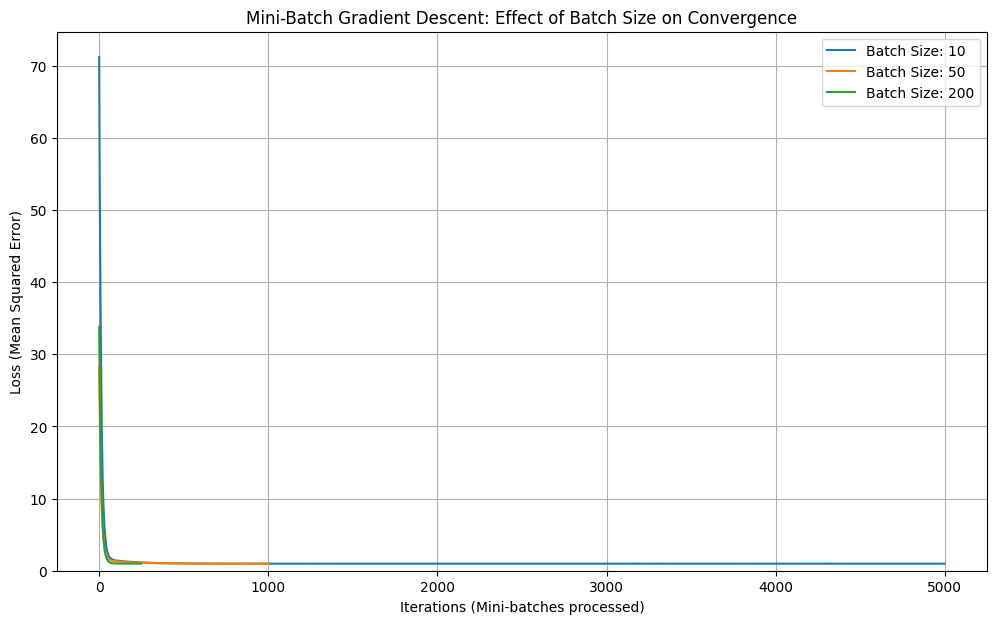

Analysis of Batch Size:

- Small Batch Size (10): The convergence path is quite noisy (similar to SGD) but can make rapid progress and potentially escape shallow local minima. Each update is faster to compute but less stable.
- Medium Batch Size (50): Offers a good balance between the stability of Batch GD and the speed of SGD. The convergence is smoother than small batches but still allows for relatively quick updates.
- Large Batch Size (200): The convergence path is much smoother (closer to Batch GD) but updates are less frequent per epoch and can be slower overall on large datasets. It might struggle to escape local minima if the landscape is complex.

Choosing an optimal batch size often involves a trade-off between computational efficiency, convergence speed, and generalization performance. Typically, batch sizes of 32, 64, 128, or 256 are common choices.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X_mb = 2 * np.random.rand(1000, 1)
y_mb = 4 + 3 * X_mb + np.random.randn(1000, 1)
X_b_mb = np.c_[np.ones((1000, 1)), X_mb]

def mse_cost_mb(X, y, theta):
    return np.mean((X @ theta - y)**2)

def mini_batch_gradient_descent(X, y, learning_rate, n_epochs, batch_size):
    m = len(y)
    theta = np.random.randn(X.shape[1], 1)
    losses = []

    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(m)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]

            grad = 2/len(yi) * xi.T @ (xi @ theta - yi)
            theta = theta - learning_rate * grad
            losses.append(mse_cost_mb(X, y, theta)) # Evaluate loss on full dataset for tracking
    return theta, losses

learning_rate_mb = 0.01
n_epochs_mb = 50

batch_size_small = 10
batch_size_medium = 50
batch_size_large = 200

theta_small, losses_small = mini_batch_gradient_descent(X_b_mb, y_mb, learning_rate_mb, n_epochs_mb, batch_size_small)
theta_medium, losses_medium = mini_batch_gradient_descent(X_b_mb, y_mb, learning_rate_mb, n_epochs_mb, batch_size_medium)
theta_large, losses_large = mini_batch_gradient_descent(X_b_mb, y_mb, learning_rate_mb, n_epochs_mb, batch_size_large)

plt.figure(figsize=(12, 7))
plt.plot(losses_small, label=f'Batch Size: {batch_size_small}')
plt.plot(losses_medium, label=f'Batch Size: {batch_size_medium}')
plt.plot(losses_large, label=f'Batch Size: {batch_size_large}')
plt.xlabel('Iterations (Mini-batches processed)')
plt.ylabel('Loss (Mean Squared Error)')
plt.title('Mini-Batch Gradient Descent: Effect of Batch Size on Convergence')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

print("Analysis of Batch Size:\n")
print(f"- Small Batch Size ({batch_size_small}): The convergence path is quite noisy (similar to SGD) but can make rapid progress and potentially escape shallow local minima. Each update is faster to compute but less stable.")
print(f"- Medium Batch Size ({batch_size_medium}): Offers a good balance between the stability of Batch GD and the speed of SGD. The convergence is smoother than small batches but still allows for relatively quick updates.")
print(f"- Large Batch Size ({batch_size_large}): The convergence path is much smoother (closer to Batch GD) but updates are less frequent per epoch and can be slower overall on large datasets. It might struggle to escape local minima if the landscape is complex.")
print("\nChoosing an optimal batch size often involves a trade-off between computational efficiency, convergence speed, and generalization performance. Typically, batch sizes of 32, 64, 128, or 256 are common choices.")

## 10. Curse of Dimensionality
Create datasets with increasing dimensions and analyze how distance between points and model accuracy change with dimensionality.

--- Analyzing Distance Between Points with Increasing Dimensions ---
Dimensions: 2, Average Pairwise Distance: 0.5326, Std Dev: 0.2501
Dimensions: 10, Average Pairwise Distance: 1.3039, Std Dev: 0.2507
Dimensions: 50, Average Pairwise Distance: 2.8848, Std Dev: 0.2373
Dimensions: 100, Average Pairwise Distance: 4.0810, Std Dev: 0.2563
Dimensions: 200, Average Pairwise Distance: 5.7540, Std Dev: 0.2469
Dimensions: 500, Average Pairwise Distance: 9.1307, Std Dev: 0.2394
Dimensions: 1000, Average Pairwise Distance: 12.9371, Std Dev: 0.2388


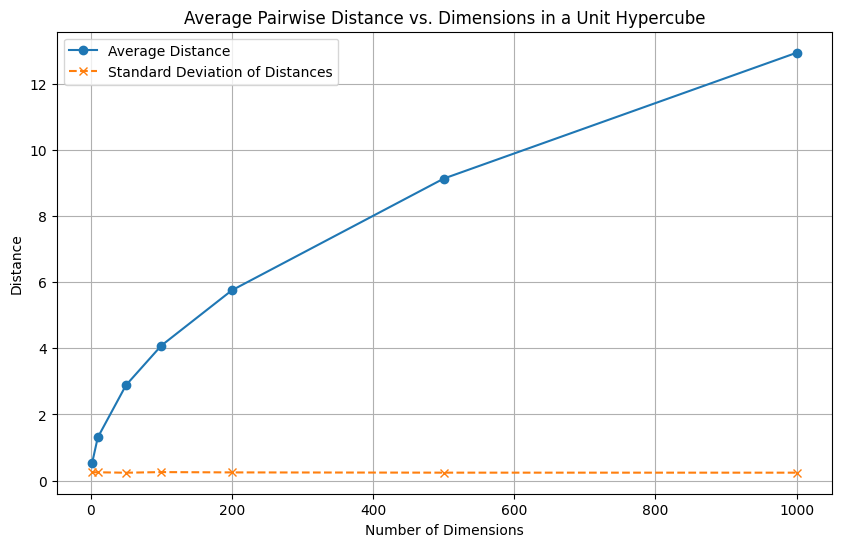


Analysis of Distance:
- As the number of dimensions increases, the average distance between randomly sampled points in a fixed-size space (like a unit hypercube) also tends to increase.
- More importantly, the standard deviation of these distances tends to decrease relative to the mean, meaning all points become 'far apart' from each other and the data becomes sparse.
- This phenomenon implies that in high dimensions, distances become less meaningful as a differentiator between points, making concepts like 'nearest neighbors' less robust.

--- Analyzing Model Accuracy with Increasing Dimensions ---
Dimensions: 2, KNN Accuracy: 0.8000
Dimensions: 5, KNN Accuracy: 0.8500
Dimensions: 10, KNN Accuracy: 0.7833
Dimensions: 20, KNN Accuracy: 0.7500
Dimensions: 50, KNN Accuracy: 0.7500
Dimensions: 100, KNN Accuracy: 0.5167
Dimensions: 200, KNN Accuracy: 0.6000
Dimensions: 300, KNN Accuracy: 0.6000
Dimensions: 400, KNN Accuracy: 0.6333
Dimensions: 500, KNN Accuracy: 0.5167


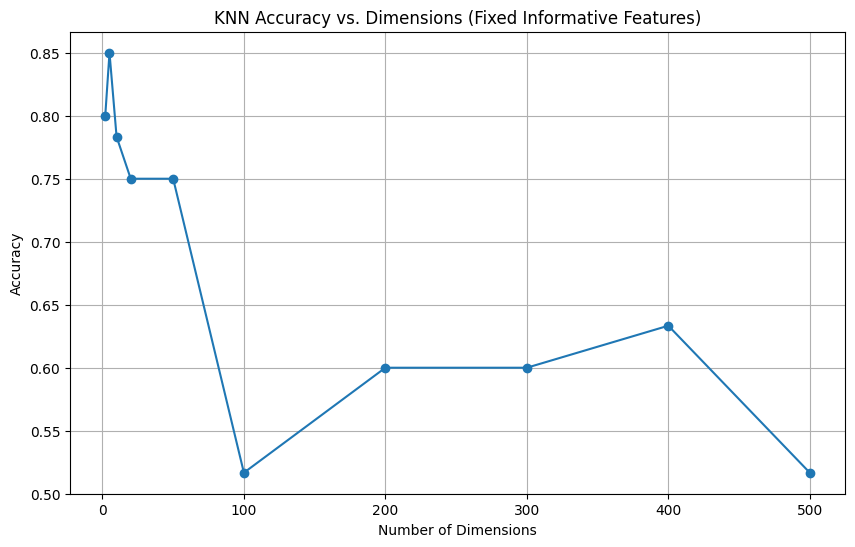


Analysis of Model Accuracy:
- With a fixed number of truly informative features, as the total number of dimensions (features) increases, the accuracy of the model (especially distance-based models like KNN) tends to decrease.
- This is because the additional non-informative dimensions add noise and make it harder for the model to find the true underlying patterns.
- In high-dimensional spaces, the data becomes extremely sparse, and the 'local' neighborhood of a point (which KNN relies on) becomes less well-defined. This leads to increased computational cost and often degraded performance.
- Dimensionality reduction techniques are often used to mitigate the effects of the curse of dimensionality by projecting high-dimensional data into a lower-dimensional space while preserving essential information.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("--- Analyzing Distance Between Points with Increasing Dimensions ---")

# Function to generate random points and calculate average pairwise distance
def analyze_distances(dimensions, num_points=100):
    # Generate points in a unit hypercube [0, 1]^D
    points = np.random.rand(num_points, dimensions)
    # Calculate all pairwise Euclidean distances
    distances = pdist(points, 'euclidean')
    return np.mean(distances), np.std(distances)

dimensions_to_test = [2, 10, 50, 100, 200, 500, 1000]
avg_distances = []
std_distances = []

for d in dimensions_to_test:
    avg_dist, std_dist = analyze_distances(d)
    avg_distances.append(avg_dist)
    std_distances.append(std_dist)
    print(f"Dimensions: {d}, Average Pairwise Distance: {avg_dist:.4f}, Std Dev: {std_dist:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(dimensions_to_test, avg_distances, marker='o', linestyle='-', label='Average Distance')
plt.plot(dimensions_to_test, std_distances, marker='x', linestyle='--', label='Standard Deviation of Distances')
plt.xlabel('Number of Dimensions')
plt.ylabel('Distance')
plt.title('Average Pairwise Distance vs. Dimensions in a Unit Hypercube')
plt.legend()
plt.grid(True)
plt.show()

print("\nAnalysis of Distance:\n- As the number of dimensions increases, the average distance between randomly sampled points in a fixed-size space (like a unit hypercube) also tends to increase.")
print("- More importantly, the standard deviation of these distances tends to decrease relative to the mean, meaning all points become 'far apart' from each other and the data becomes sparse.")
print("- This phenomenon implies that in high dimensions, distances become less meaningful as a differentiator between points, making concepts like 'nearest neighbors' less robust.")

print("\n--- Analyzing Model Accuracy with Increasing Dimensions ---")

# Function to generate synthetic classification data and train a classifier
def analyze_model_accuracy(dimensions, num_samples=200, informative_features=2, random_state=42):
    X, y = make_classification(n_samples=num_samples, n_features=dimensions,
                               n_informative=informative_features, n_redundant=0, n_repeated=0,
                               n_clusters_per_class=1, random_state=random_state)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

    # Train a K-Nearest Neighbors classifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    return accuracy_score(y_test, y_pred)

dimensions_for_accuracy = [2, 5, 10, 20, 50, 100, 200, 300, 400, 500]
accuracies = []

for d in dimensions_for_accuracy:
    # Keep number of informative features low to simulate 'curse'
    accuracy = analyze_model_accuracy(d, informative_features=2)
    accuracies.append(accuracy)
    print(f"Dimensions: {d}, KNN Accuracy: {accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(dimensions_for_accuracy, accuracies, marker='o', linestyle='-')
plt.xlabel('Number of Dimensions')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs. Dimensions (Fixed Informative Features)')
plt.grid(True)
plt.show()

print("\nAnalysis of Model Accuracy:\n- With a fixed number of truly informative features, as the total number of dimensions (features) increases, the accuracy of the model (especially distance-based models like KNN) tends to decrease.")
print("- This is because the additional non-informative dimensions add noise and make it harder for the model to find the true underlying patterns.")
print("- In high-dimensional spaces, the data becomes extremely sparse, and the 'local' neighborhood of a point (which KNN relies on) becomes less well-defined. This leads to increased computational cost and often degraded performance.")
print("- Dimensionality reduction techniques are often used to mitigate the effects of the curse of dimensionality by projecting high-dimensional data into a lower-dimensional space while preserving essential information.")